# Seaborn — ⭐⭐⭐⭐

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Using Seaborn's built-in tips dataset
tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [12]:
# Using Seaborn's built-in datasets
flights = sns.load_dataset("flights")
flights

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


### 1. `sns.histplot()` — Binned Frequency Distribution
`histplot()` is the modern Seaborn replacement for the older `distplot()`. It groups data points into intervals (bins) and plots the count, density, or probability.

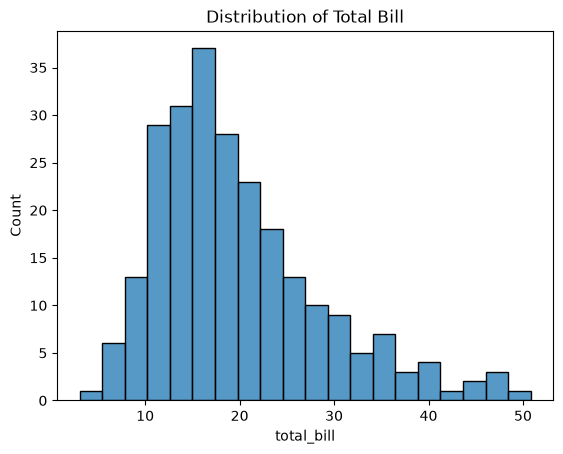

In [5]:
sns.histplot(data=tips, x="total_bill", bins=20)
plt.title("Distribution of Total Bill")
plt.show()

#### Key Capabilities & Useful Parameters
- Overlaying a smooth curve (`kde=True`): Combines the histogram with a KDE line in one plot.

<Axes: xlabel='total_bill', ylabel='Count'>

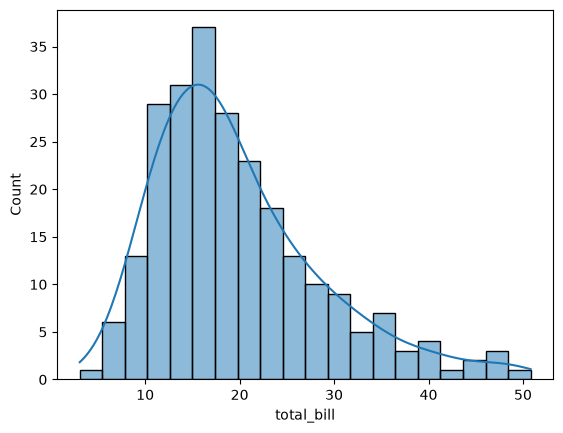

In [6]:
sns.histplot(data=tips, x="total_bill", bins=20, kde=True)

#### Comparing groups with `hue` and `element`:

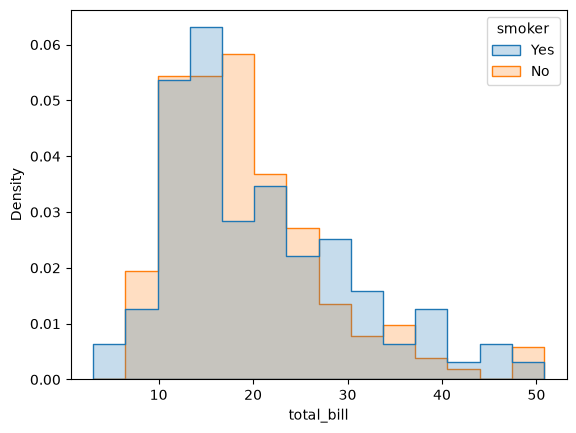

In [7]:
# Compare distribution by smoker status using stepped outlines
sns.histplot(
    data=tips,
    x="total_bill",
    hue="smoker",
    element="step",         # 'bars', 'step', or 'poly'
    stat="density",         # 'count', 'frequency', 'probability', 'percent', 'density'
    common_norm=False       # Normalize each hue group independently
)
plt.show()

## 2. `sns.kdeplot()` — Kernel Density Estimation
`kdeplot()` computes and plots a **Kernel Density Estimate—**a non-parametric way to estimate the probability density function of a continuous variable using Gaussian kernels. The area under the entire curve sums to 1.

**Basic 1D Density Curve**

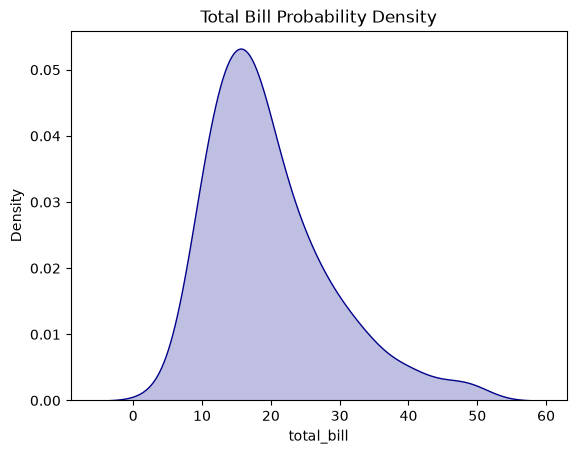

In [8]:
sns.kdeplot(
    data=tips,
    x="total_bill",
    fill=True,
    color="darkblue"
)
plt.title("Total Bill Probability Density")
plt.show()

**Key Capabilities & Useful Parameters**

- **Controlling smoothness** (`bw_adjust`):

    Adjusts the bandwidth. Values lower than 1 (e.g., `0.5`) make the curve more sensitive and jagged; values greater than 1 (e.g., `2.0`) make it smoother.

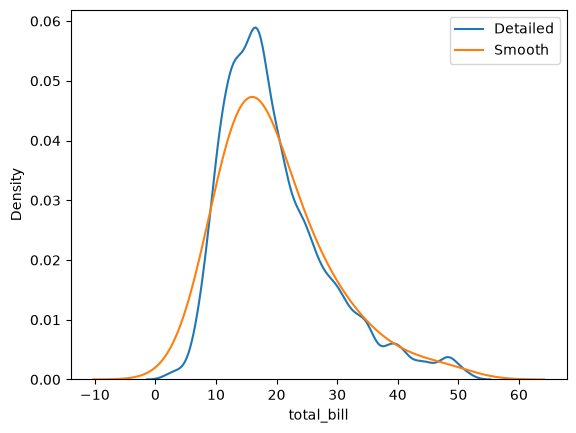

In [9]:
# Finer detail vs over-smoothed
sns.kdeplot(data=tips, x="total_bill", bw_adjust=0.5, label="Detailed")
sns.kdeplot(data=tips, x="total_bill", bw_adjust=1.5, label="Smooth")
plt.legend()
plt.show()

- Group Comparisons with hue:

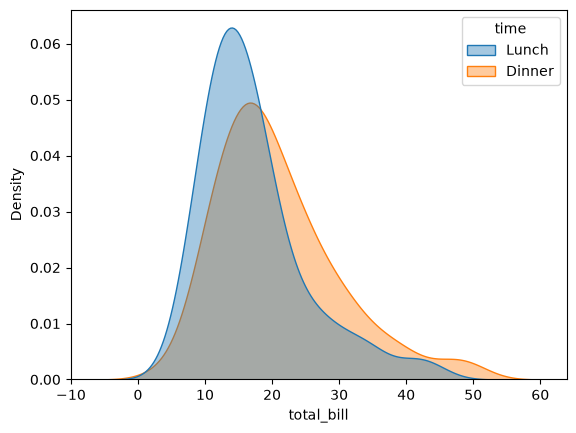

In [10]:
sns.kdeplot(
    data=tips, 
    x="total_bill", 
    hue="time",           # Lunch vs Dinner
    fill=True, 
    common_norm=False, 
    alpha=0.4
)
plt.show()

- **2D Contour KDE Plot:**

    Passing x and y visualizes the joint distribution as a topographic-like contour map.

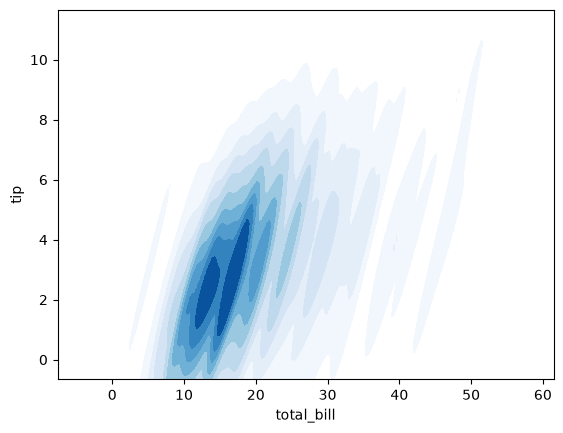

In [11]:
sns.kdeplot(
    data=tips, 
    x="total_bill", 
    y="tip", 
    fill=True,            # Fills contours with color gradients
    thresh=0.05,          # Drops the lowest 5% outer density
    cmap="Blues"
)
plt.show()

**When to Use Which?**
- Use `histplot()` when you want to see the **true raw sample counts**, check for gaps or discrete rounding spikes in real data, or present findings to a non-technical audience.

- Use `kdeplot()` when comparing multiple distributions overlaid on the same chart (histograms look cluttered when stacked), or when you want an estimate of the underlying population shape.

- **Caution with KDE**: Kernel smoothing can sometimes create artifacts, like extending curves into negative values for variables that cannot physically be negative (e.g., age, prices). Use `cut=0` in `kdeplot()` to clip curves at the dataset boundary.

## 3. `sns.scatterplot()` — Bivariate Relationships & Encoding
`ssns.scatterplot()` maps individual observations as coordinate points $(x, y)$. Unlike Matplotlib's `plt.scatter()`, Seaborn automatically parses DataFrames and builds multi-attribute legends without manual loops.

**Basic Usage**

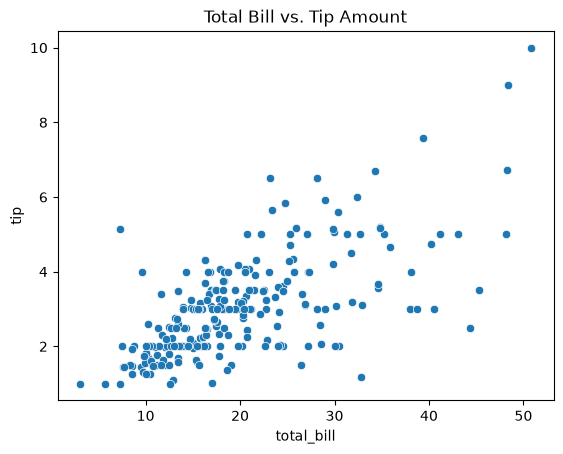

In [13]:
sns.scatterplot(data=tips, x="total_bill", y="tip")
plt.title("Total Bill vs. Tip Amount")
plt.show()

**Multi-Dimensional Visual Encoding**
Encode up to 5 variables into a single view:

- `hue:` Colors points by a categorical or numerical feature.

- `style:` Changes point markers (e.g., circles, crosses) by category.

- `size:` Scales marker radius based on a continuous or integer column.

- `alpha:` Sets opacity to handle overplotting.

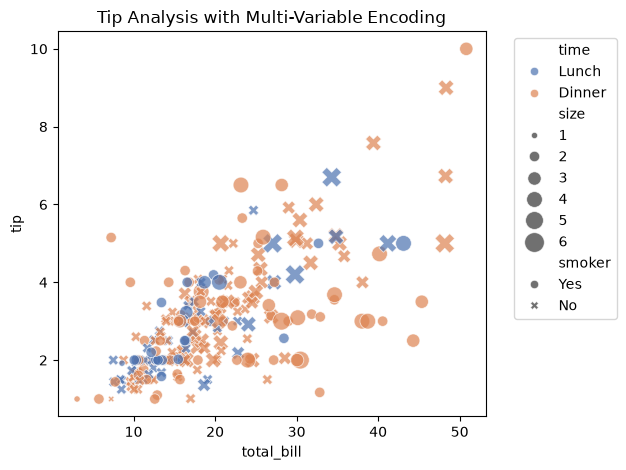

In [14]:
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="time",           # Color by Lunch vs Dinner
    style="smoker",       # Marker shapes for Smoker vs Non-Smoker
    size="size",          # Dot size scales with party size
    sizes=(20, 200),      # Min and max marker size
    alpha=0.7,
    palette="deep"
)
plt.title("Tip Analysis with Multi-Variable Encoding")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # Move legend outside
plt.tight_layout()
plt.show()

## 4. `sns.lineplot()` — Trends, Sequences & Confidence Intervals
`sns.lineplot()` connects observations sequentially along the x-axis.

Its standout feature: **automatic aggregation and confidence band estimation**. If multiple $y$-values exist for a single $x$-value (e.g., repeated measurements across subjects or years), lineplot calculates the mean line and automatically draws a shaded **95% bootstrap confidence interval (CI)**.

**Aggregation with Shaded Confidence Intervals**

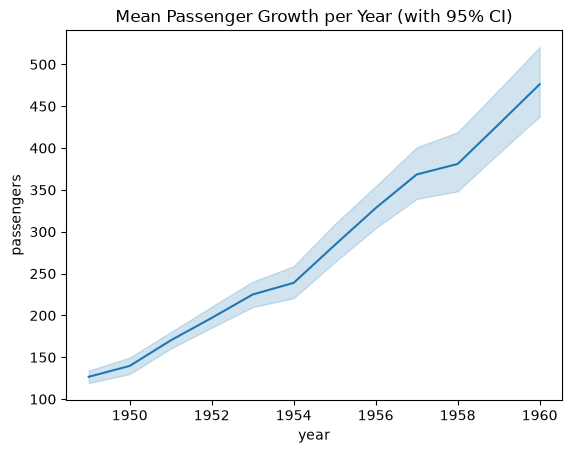

In [15]:
# The 'flights' dataset has 12 monthly readings per year
sns.lineplot(
    data=flights, 
    x="year", 
    y="passengers",
    errorbar="ci"         # Shaded band = 95% CI (default); set errorbar=None to turn off
)
plt.title("Mean Passenger Growth per Year (with 95% CI)")
plt.show()

**Multi-Series Comparison with `hue` and `style`**

Separate trends by category without manual subsetting:

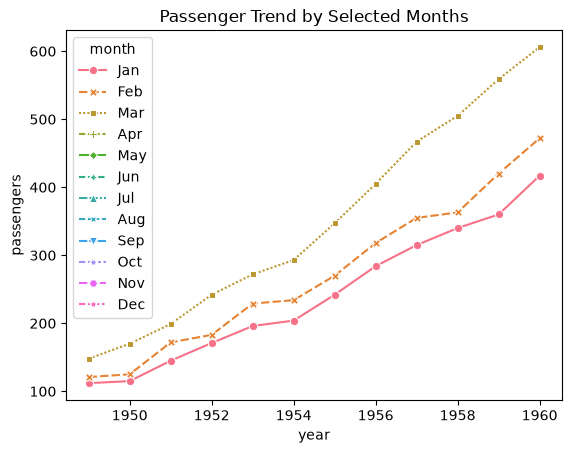

In [16]:
# Compare trends across months or specific groups
sns.lineplot(
    data=flights.query("month in ['Jan', 'May', 'Aug']"),
    x="year",
    y="passengers",
    hue="month",          # Different line colors per month
    style="month",        # Solid vs dashed line patterns
    markers=True,         # Place distinct points on data coordinates
    dashes=True
)
plt.title("Passenger Trend by Selected Months")
plt.show()

**Controlling the Aggregation Statistic (estimator)**

By default, the central line represents the mean. Change it to median or standard deviation:

<Axes: xlabel='year', ylabel='passengers'>

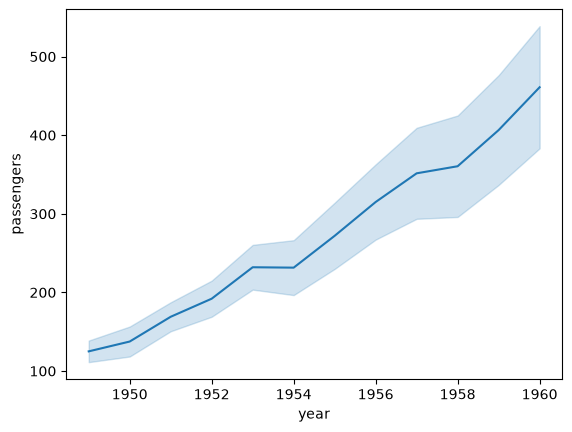

In [17]:
# Plot the median instead of the mean, with standard deviation bands
sns.lineplot(
    data=flights,
    x="year",
    y="passengers",
    estimator="median",
    errorbar="sd"         # Shaded area represents ±1 Standard Deviation
)

## 5. `sns.countplot()` — Category Frequency (Row Count)

`countplot()` functions like a visual `df['column'].value_counts()`. It answers: "How many times does each category appear in the dataset?"

**Basic Count Plot**

C:\Users\mdkha\AppData\Local\Temp\ipykernel_9492\3298847823.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=tips, x="day", palette="Blues_d")


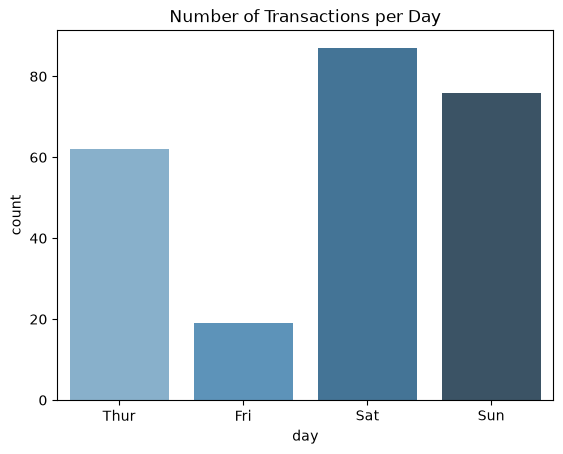

In [18]:
# How many bills were recorded on each day?
sns.countplot(data=tips, x="day", palette="Blues_d")
plt.title("Number of Transactions per Day")
plt.show()

**Key Capabilities & Parameters**
- **Subdividing with** `hue`:
    
    plit counts by a second categorical variable.

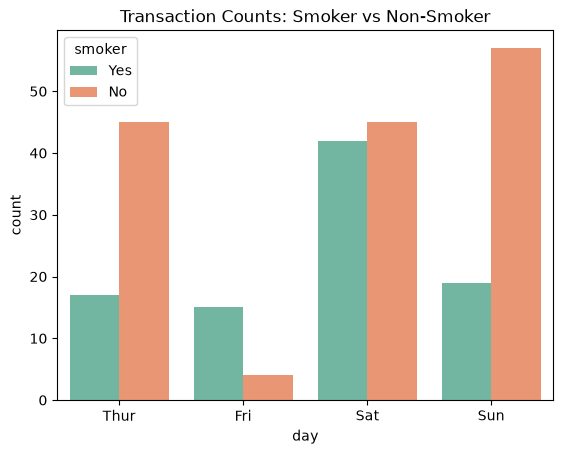

In [19]:
# Count transactions per day, broken down by smoker status
sns.countplot(data=tips, x="day", hue="smoker", palette="Set2")
plt.title("Transaction Counts: Smoker vs Non-Smoker")
plt.show()

**Horizontal Layout:**

Pass the category to `y` instead of `x` (useful when category label text is long).

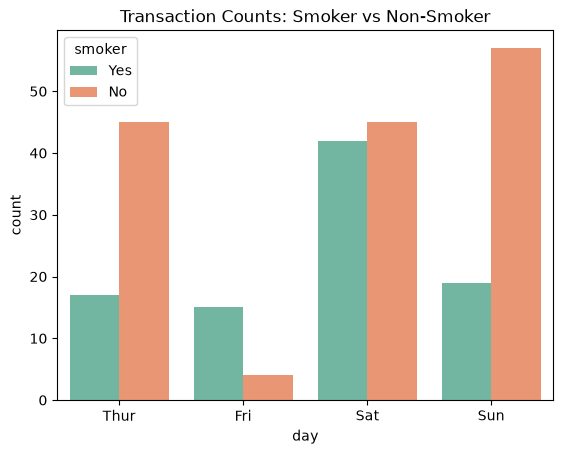

In [20]:
# Count transactions per day, broken down by smoker status
sns.countplot(data=tips, x="day", hue="smoker", palette="Set2")
plt.title("Transaction Counts: Smoker vs Non-Smoker")
plt.show()

- **Custom Order (`order=`):**

Sort bars by specific days or descending frequency:

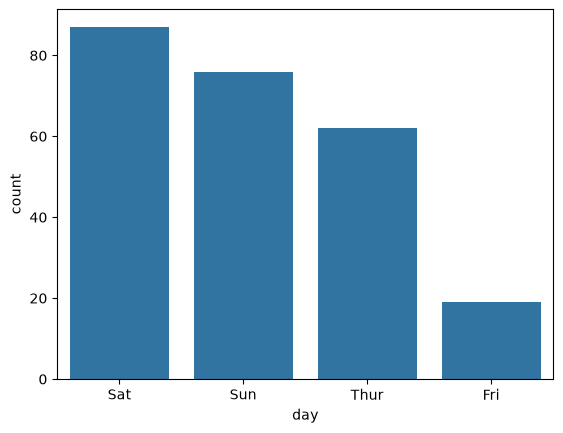

In [21]:
# Order by most frequent to least frequent day
day_order = tips["day"].value_counts().index
sns.countplot(data=tips, x="day", order=day_order)
plt.show()

## 6. sns.barplot() — Aggregation & Uncertainty

`barplot()` computes an aggregate statistic (default: **mean**) of a numeric variable grouped by category. The black lines at the top of each bar are **error bars**, representing the 95% bootstrap confidence interval of that mean.

**Basic Bar Plot**

C:\Users\mdkha\AppData\Local\Temp\ipykernel_9492\1856516665.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x="day", y="total_bill", palette="muted")


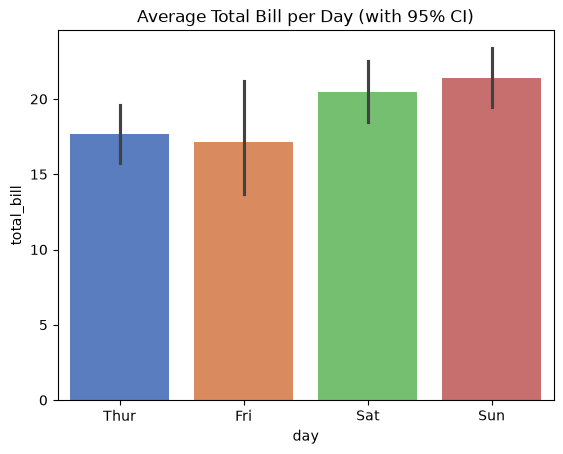

In [22]:
# What is the average total bill on each day?
sns.barplot(data=tips, x="day", y="total_bill", palette="muted")
plt.title("Average Total Bill per Day (with 95% CI)")
plt.show()

**Key Capabilities & Parameters**

- **Changing the Aggregation (`estimator`):**

    By default, `estimator="mean"`. You can supply any summary function, such as `sum`, `median`, `np.std`, or `min`.

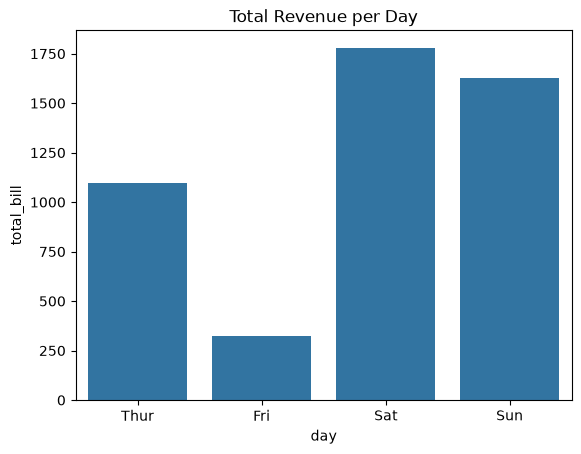

In [25]:
# Total sum of bills per day instead of the mean
sns.barplot(
    data=tips, 
    x="day", 
    y="total_bill", 
    estimator=np.sum, 
    errorbar=None  # Turn off error bars when displaying direct totals
)
plt.title("Total Revenue per Day")
plt.show()

- **Controlling Error Bars (`errorbar`):**

    - `errorbar="ci"` *(default, 95% confidence interval)*
    - `errorbar="sd"` *(Standard deviation — shows data spread rather than uncertainty)*
    - `errorbar=None` *(Removes the error bar completely)*

<Axes: xlabel='day', ylabel='total_bill'>

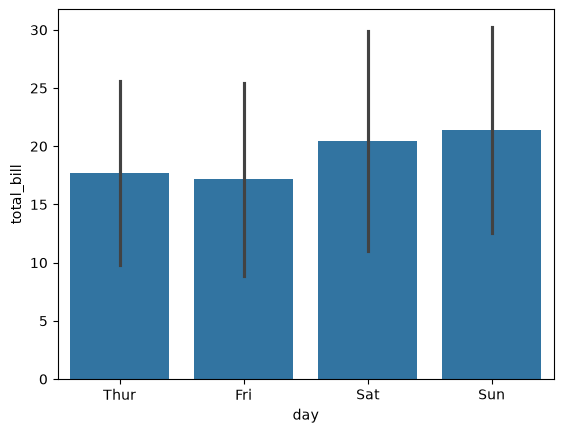

In [26]:
# Show spread with standard deviation
sns.barplot(data=tips, x="day", y="total_bill", errorbar="sd")

**Group Comparisons with `hue`:**

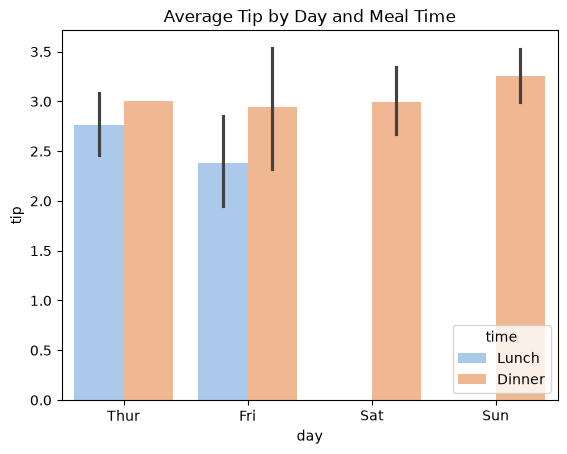

In [27]:
# Compare average tip amounts between Lunch and Dinner across days
sns.barplot(data=tips, x="day", y="tip", hue="time", palette="pastel")
plt.title("Average Tip by Day and Meal Time")
plt.show()

## 7. `sns.boxplot()` - Box plots

`sns.boxplot()` visualizes the five-number summary and outliers of a dataset across categorical groups using standard Tukey box-and-whisker conventions.

**Basic Setup and Syntax**

C:\Users\mdkha\AppData\Local\Temp\ipykernel_9492\1839555285.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x="day", y="total_bill", palette="Set2")


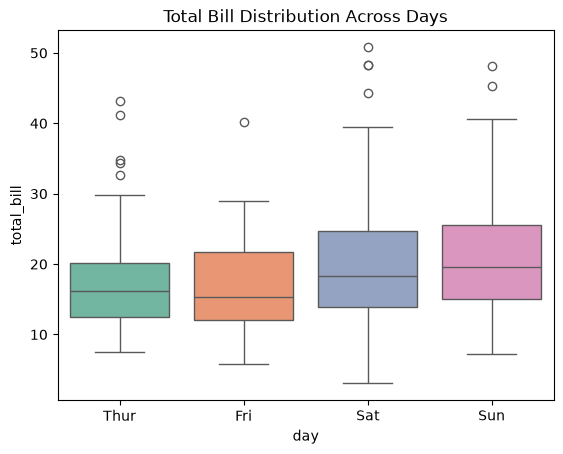

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

# Distribution of 'total_bill' across different 'days'
sns.boxplot(data=tips, x="day", y="total_bill", palette="Set2")

plt.title("Total Bill Distribution Across Days")
plt.show()

**Key Parameters and Common Use Cases**

**Sub-grouping with `hue`**

Split each category by a second categorical feature to compare sub-populations side by side.

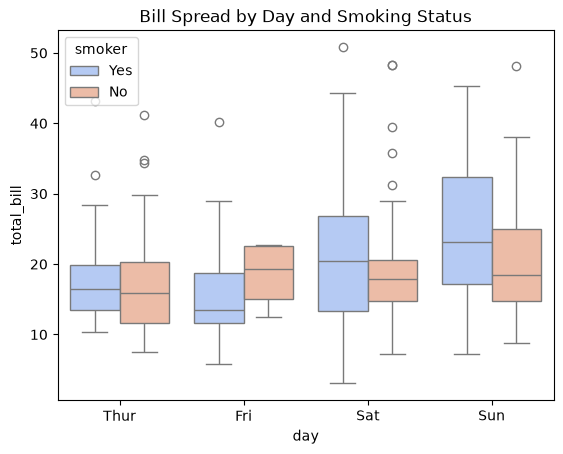

In [29]:
# Compare total bills per day between Smokers and Non-Smokers
sns.boxplot(
    data=tips, 
    x="day", 
    y="total_bill", 
    hue="smoker", 
    palette="coolwarm"
)
plt.title("Bill Spread by Day and Smoking Status")
plt.show()

**Horizontal Layout**

Swap the `x` and `y` axes so the numeric distribution lies on `x`. This is useful when categorical labels are long or numerous.

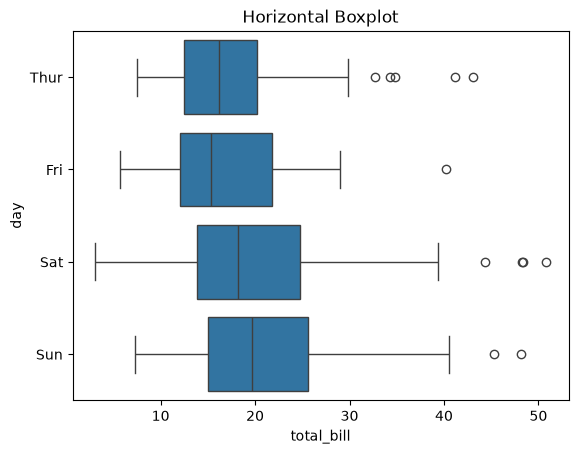

In [30]:
sns.boxplot(data=tips, x="total_bill", y="day")
plt.title("Horizontal Boxplot")
plt.show()

**Single-Variable Summary**

Pass only one continuous variable without an `x` or `y` category to inspect the global distribution of a single feature.

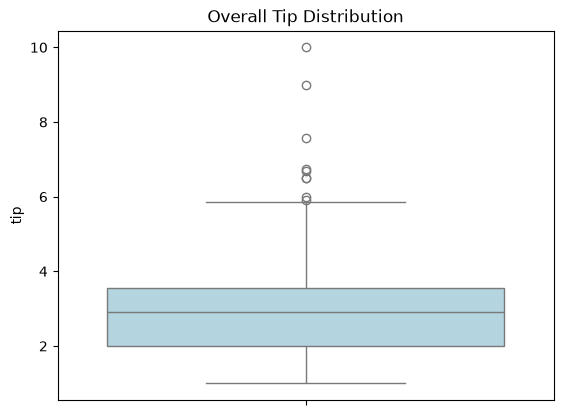

In [31]:
# Global check for outliers in tip values
sns.boxplot(data=tips, y="tip", color="lightblue")
plt.title("Overall Tip Distribution")
plt.show()

**Styling Box Features**

Customize whisker coverage, line widths, and outlier styling:

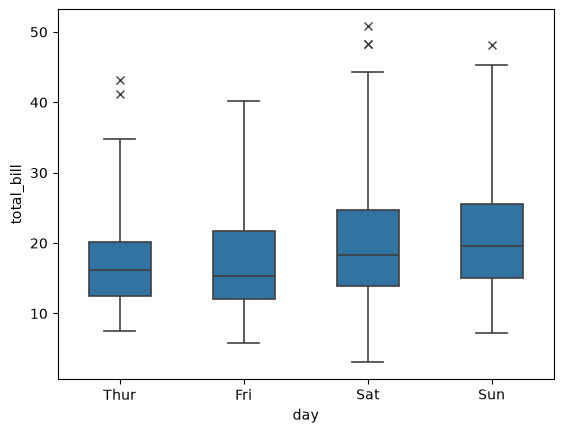

In [32]:
sns.boxplot(
    data=tips,
    x="day",
    y="total_bill",
    whis=2.0,                  # Extend whiskers to 2.0 * IQR (default is 1.5)
    width=0.5,                 # Narrow the box width
    linewidth=1.2,             # Border line thickness
    flierprops={               # Style the outlier points
        "marker": "x",
        "markerfacecolor": "red",
        "markersize": 6
    }
)
plt.show()

**Advanced Combo: Overlaying Strip / Swarm Plots**

A box plot summarizes distributions well, but hides sample size (e.g., whether a box represents 10 rows or 10,000). Overlaying `sns.stripplot()` reveals raw data density on top of the quartile markers.

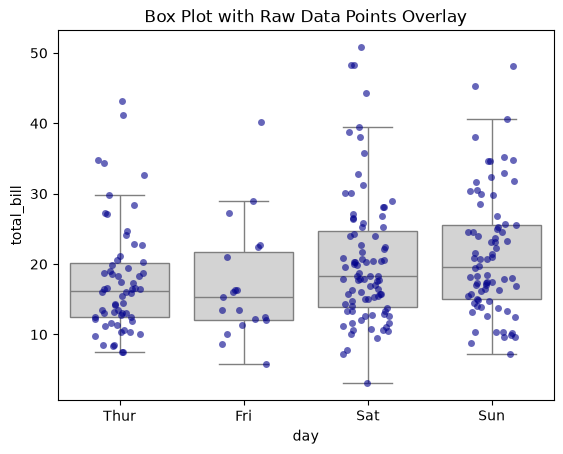

In [33]:
# 1. Base boxplot with muted colors
sns.boxplot(
    data=tips, 
    x="day", 
    y="total_bill", 
    color="lightgray", 
    fliersize=0  # Hide default outliers so stripplot doesn't double-plot them
)

# 2. Overlay individual points with jitter
sns.stripplot(
    data=tips, 
    x="day", 
    y="total_bill", 
    color="darkblue", 
    alpha=0.6, 
    jitter=0.2, 
    size=5
)

plt.title("Box Plot with Raw Data Points Overlay")
plt.show()

## 8. `sns.heatmap()`

`sns.heatmap()` visualizes 2D rectangular data as a color-encoded matrix. Each cell's color corresponds to its numerical value on a gradient scale.

In data science and machine learning, its two primary use cases are displaying **correlation matrices** (feature-to-feature relationships) and **confusion matrices** (classification model accuracy).

**Setup and Data Requirement**

**Key Rule:** *Unlike other Seaborn functions, `sns.heatmap()` requires a 2D matrix where both rows and columns have labels, and all cell values are numerical (such as the output of `df.corr()`, `pd.crosstab()`, or `pd.pivot_table()`).*

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using Seaborn's built-in tips dataset
tips = sns.load_dataset("tips")

# Compute Pearson correlation matrix across numeric columns
corr_matrix = tips.corr(numeric_only=True)
print(corr_matrix)

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


**1. Basic Heatmap**

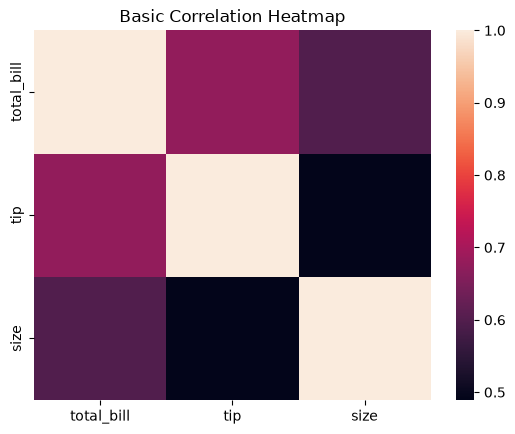

In [35]:
sns.heatmap(corr_matrix)
plt.title("Basic Correlation Heatmap")
plt.show()

**2. The Production-Ready Correlation Heatmap**

To make a heatmap readable and informative, use these standard parameters:

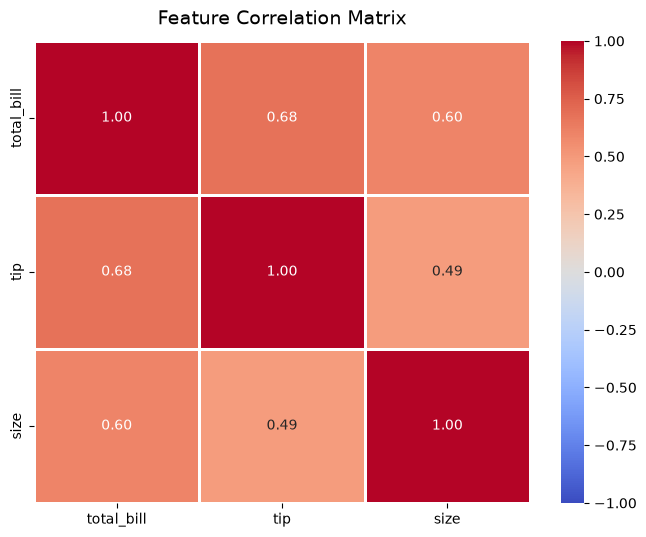

In [36]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,          # Write data values directly inside each cell
    fmt=".2f",           # Format numbers to 2 decimal places
    cmap="coolwarm",     # Diverging colormap (blue = negative, red = positive)
    vmin=-1.0,           # Lower anchor for colormap (correlations range from -1 to 1)
    vmax=1.0,            # Upper anchor for colormap
    center=0,            # Value where the colormap centers (white/neutral)
    linewidths=1.0,      # Grid lines separating cells
    linecolor="white",   # Color of cell dividers
    cbar=True            # Show the color bar legend
)

plt.title("Feature Correlation Matrix", fontsize=14, pad=12)
plt.show()

**Parameter Breakdown**

- `annot=True`: Prints numeric values inside the cells.
- `fmt`: Controls string formatting (e.g., `".2f"` for 2 decimal places, `"d"` for raw integers in a confusion matrix).
- `cmap`: Choose colors deliberately:
    - **Diverging** (`"coolwarm"`, `"vlag"`, `"Spectral"`): Best for metrics with a neutral midpoint (like correlation centered at `0`).
    - **Sequential** (`"Blues"`, `"viridis"`, `"rocket"`): Best for positive frequencies or amounts starting at `0`.
- `vmin`, `vmax`, `center`: Anchor color scales so that colors are not skewed by arbitrary local minimums or maximums.

**3. Hiding Redundant Halves (mask=)**

Correlation matrices are symmetrical across the diagonal. Displaying both triangles wastes space and creates visual clutter. Use a boolean NumPy mask to display only the lower triangle:

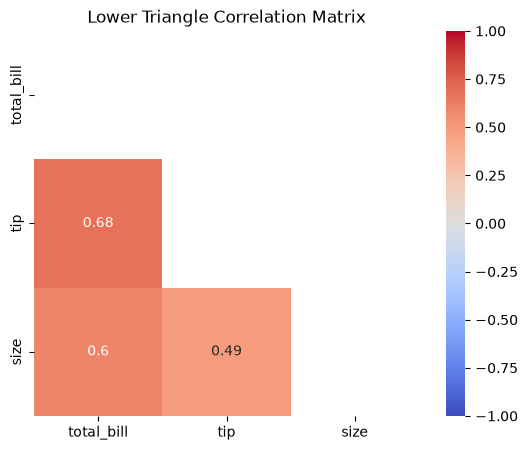

In [37]:
import numpy as np

# Create a boolean upper triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix, 
    mask=mask,           # Cells marked True are hidden
    annot=True, 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    center=0,
    square=True          # Forces cells to be perfectly square
)

plt.title("Lower Triangle Correlation Matrix")
plt.show()

**4. Heatmap from a Pivot Table (e.g., Flights Dataset)**

Heatmaps are also used to visualize 2D categorical matrices, such as seasonal trends over time:

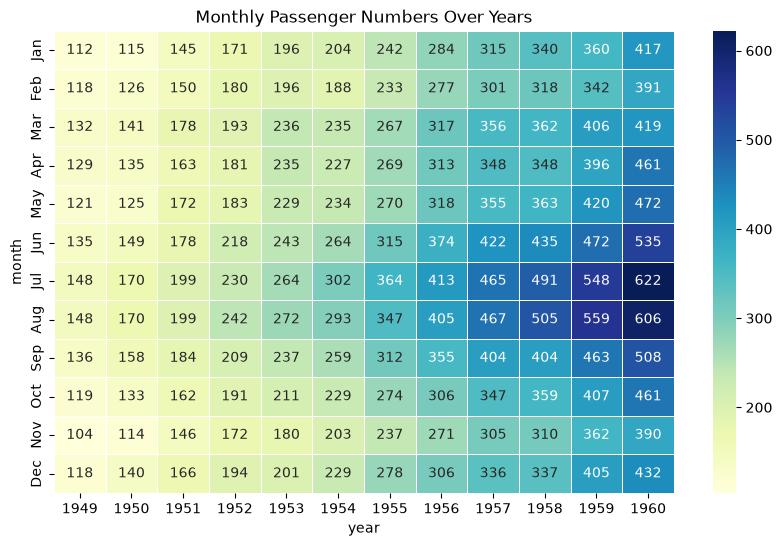

In [38]:
flights = sns.load_dataset("flights")

# Reshape into a 2D matrix: Months vs Years
flights_matrix = flights.pivot(index="month", columns="year", values="passengers")

plt.figure(figsize=(10, 6))
sns.heatmap(
    flights_matrix, 
    cmap="YlGnBu",       # Sequential yellow-green-blue gradient
    fmt="d",             # Format as integer counts
    annot=True, 
    linewidths=0.5
)

plt.title("Monthly Passenger Numbers Over Years")
plt.show()